In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\DELL\Downloads\Sleep_health_and_lifestyle_dataset.csv")
print(df.head())
df.columns

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80          75      

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [17]:
df.shape

(374, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [2]:
df[['Systolic_BP','Diastolic_BP']]=df['Blood Pressure'].str.split('/',expand=True)

In [3]:
df["Systolic_BP"]=df["Systolic_BP"].astype(int)
df["Diastolic_BP"]=df["Diastolic_BP"].astype(int)
df=df.drop(columns=["Blood Pressure"])
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [12]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
Systolic_BP                  0
Diastolic_BP                 0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [4]:
df["Sleep Disorder"]=df["Sleep Disorder"].fillna("No Disorder")

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           155 non-null    object 
 12  Systolic_BP              374 non-null    int64  
 13  Diastolic_BP             374 non-null    int64  
dtypes: float64(1), int64(9), o

In [5]:
corr=df.corr(numeric_only=True)
corr.round(4)

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
Person ID,1.0000,0.9905,0.2963,0.4316,0.1499,-0.3943,-0.2255,0.0438,0.6116,0.5907
Age,0.9905,1.0000,0.3447,0.4737,0.1790,-0.4223,-0.2256,0.0580,0.6059,0.5938
Sleep Duration,0.2963,0.3447,1.0000,0.8832,0.2124,-0.8110,-0.5165,-0.0395,-0.1804,-0.1666
Quality of Sleep,0.4316,0.4737,0.8832,1.0000,0.1929,-0.8988,-0.6599,0.0168,-0.1216,-0.1102
Physical Activity Level,0.1499,0.1790,0.2124,0.1929,1.0000,-0.0341,0.1370,0.7727,0.2654,0.3827
Stress Level,-0.3943,-0.4223,-0.8110,-0.8988,-0.0341,1.0000,0.6700,0.1868,0.1028,0.0918
Heart Rate,-0.2255,-0.2256,-0.5165,-0.6599,0.1370,0.6700,1.0000,-0.0303,0.2941,0.2711
Daily Steps,0.0438,0.0580,-0.0395,0.0168,0.7727,0.1868,-0.0303,1.0000,0.1033,0.2420
Systolic_BP,0.6116,0.6059,-0.1804,-0.1216,0.2654,0.1028,0.2941,0.1033,1.0000,0.9729
Diastolic_BP,0.5907,0.5938,-0.1666,-0.1102,0.3827,0.0918,0.2711,0.2420,0.9729,1.0000


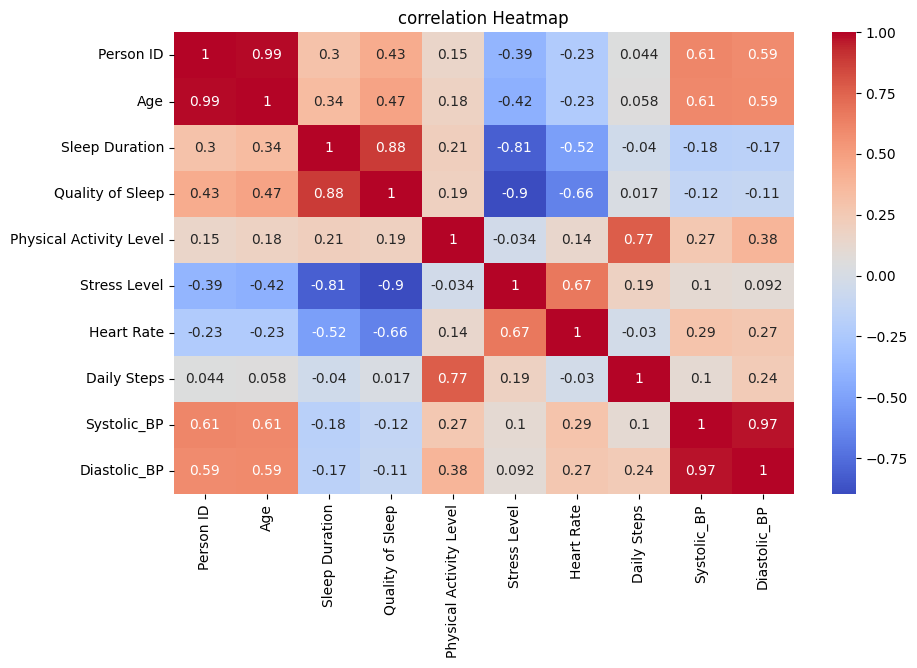

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("correlation Heatmap")
plt.show()

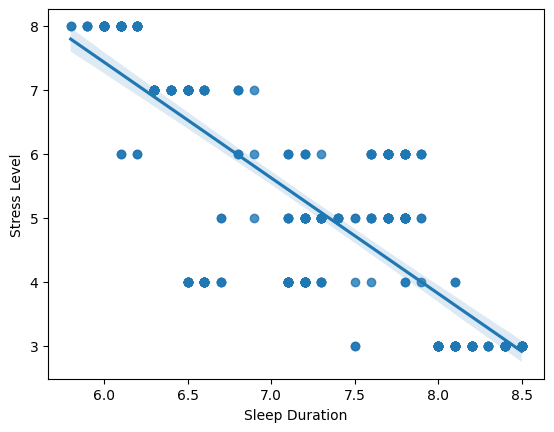

In [15]:
sns.regplot(x="Sleep Duration",y="Stress Level",data=df)
plt.show()

In [ ]:
"more sleep,less stress"

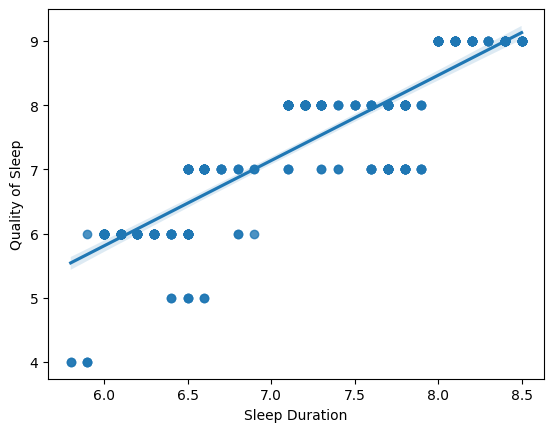

In [30]:
sns.regplot(x="Sleep Duration",y="Quality of Sleep",data=df)
plt.show()

In [ ]:
"Quality of sleep increses with sleep duration" 

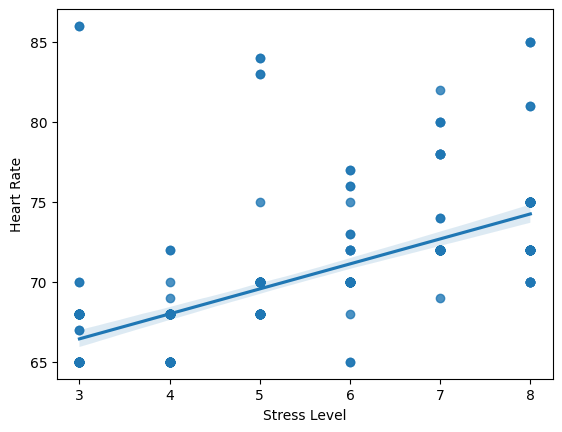

In [5]:
sns.regplot(x="Stress Level",y="Heart Rate",data = df)
plt.show()

In [ ]:
"Heart rate increases with more stress level"

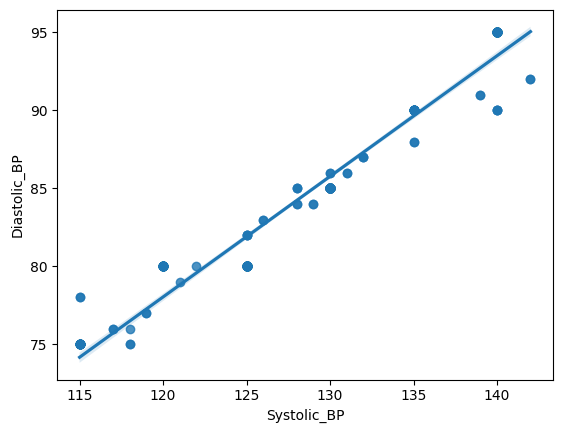

In [14]:
sns.regplot(x="Systolic_BP",y="Diastolic_BP",data=df)
plt.show()

In [ ]:
"If systolic increses diastolic will also increase"

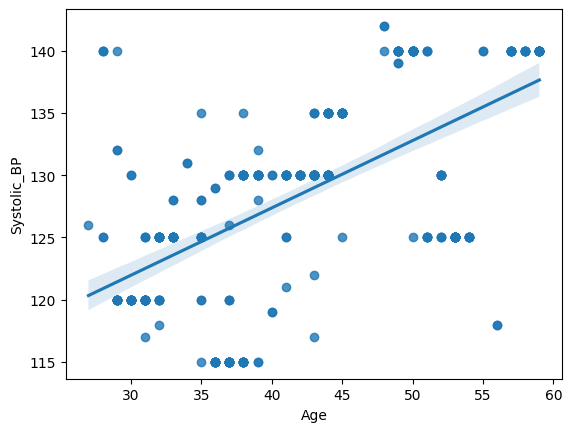

In [16]:
sns.regplot(x="Age",y="Systolic_BP",data=df)
plt.show()

In [ ]:
"systolic increses as we grow up"

In [ ]:
//categorical Analysis vs Numerical analysis//

In [38]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,No Disorder,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [8]:
df.groupby("Gender")["Sleep Duration"].mean().sort_values(ascending=False)

Gender
Female    7.229730
Male      7.036508
Name: Sleep Duration, dtype: float64

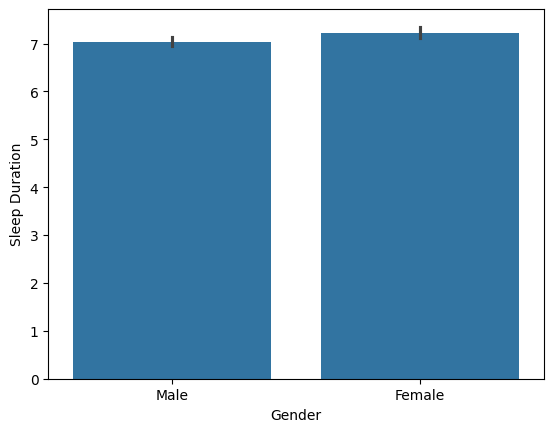

In [16]:
sns.barplot(x="Gender",y="Sleep Duration",data=df)
plt.show()

In [ ]:
"Female sleep duration is more than the male"

In [17]:
df.groupby("Gender")["Heart Rate"].mean().sort_values(ascending=False)

Gender
Male      71.052910
Female    69.259459
Name: Heart Rate, dtype: float64

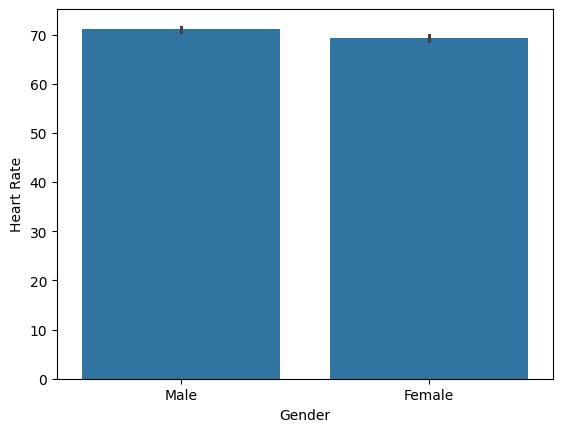

In [18]:
sns.barplot(x="Gender",y="Heart Rate",data=df)
plt.show()

In [ ]:
"male heart rate is more than female"

In [19]:
df.groupby("Gender")["Stress Level"].mean().sort_values(ascending=False)

Gender
Male      6.079365
Female    4.675676
Name: Stress Level, dtype: float64

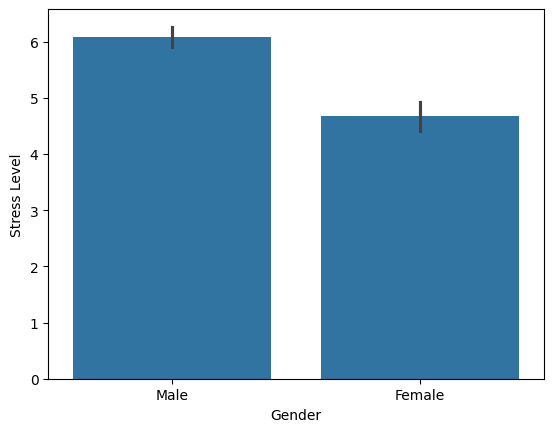

In [20]:
sns.barplot(x="Gender",y="Stress Level",data=df)
plt.show()

In [ ]:
"female have less stress comparing with male"

In [22]:
df.groupby("Occupation")["Sleep Duration"].mean().sort_values(ascending=False)

Occupation
Engineer                7.987302
Lawyer                  7.410638
Accountant              7.113514
Nurse                   7.063014
Doctor                  6.970423
Manager                 6.900000
Software Engineer       6.750000
Teacher                 6.690000
Salesperson             6.403125
Scientist               6.000000
Sales Representative    5.900000
Name: Sleep Duration, dtype: float64

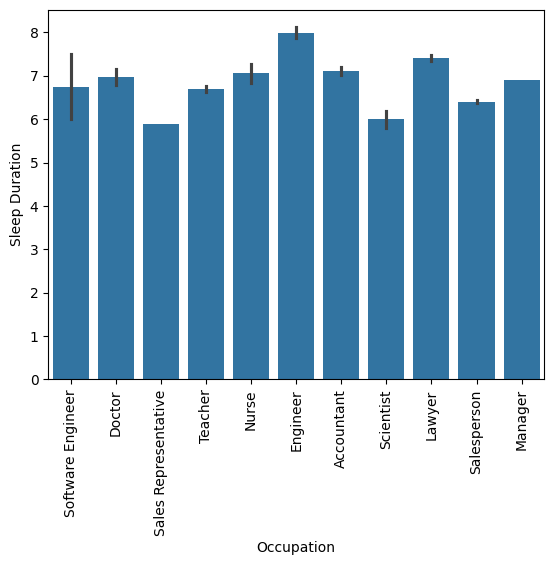

In [23]:
sns.barplot(x="Occupation",y="Sleep Duration",data=df)
plt.xticks(rotation=90)
plt.show()

In [ ]:
"sales representatives have less sleep duration comparing with all other occupations"

In [25]:
df.groupby("Occupation")["Stress Level"].mean().sort_values(ascending=False)

Occupation
Sales Representative    8.000000
Salesperson             7.000000
Scientist               7.000000
Doctor                  6.732394
Software Engineer       6.000000
Nurse                   5.547945
Lawyer                  5.063830
Manager                 5.000000
Accountant              4.594595
Teacher                 4.525000
Engineer                3.888889
Name: Stress Level, dtype: float64

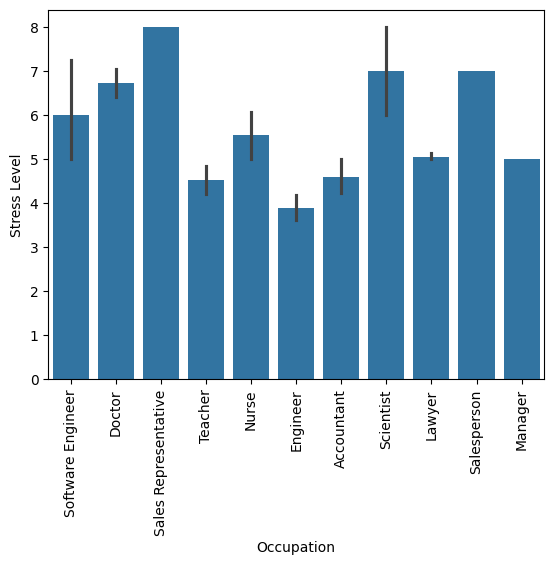

In [26]:
sns.barplot(x="Occupation",y="Stress Level",data=df)
plt.xticks(rotation=90)
plt.show()

In [ ]:
"sales representives having higher stress levels"

In [39]:
df.groupby("Sleep Disorder")["Sleep Duration"].mean().sort_values(ascending=False)

Sleep Disorder
No Disorder    7.358447
Sleep Apnea    7.032051
Insomnia       6.589610
Name: Sleep Duration, dtype: float64

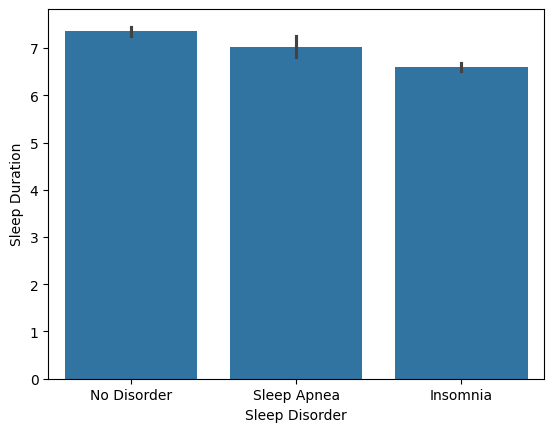

In [9]:
sns.barplot(x="Sleep Disorder",y="Sleep Duration",data=df)
plt.show()

In [ ]:
"people who are having sleep duration less than 7 hours are likely to have sleep disorders"

In [ ]:
//categorical vs categorical??

In [60]:
(pd.crosstab(df["Gender"],df["Sleep Disorder"],normalize="index")*100).round(2)

Sleep Disorder,Insomnia,No Disorder,Sleep Apnea
Gender,,,
Female,19.46,44.32,36.22
Male,21.69,72.49,5.82


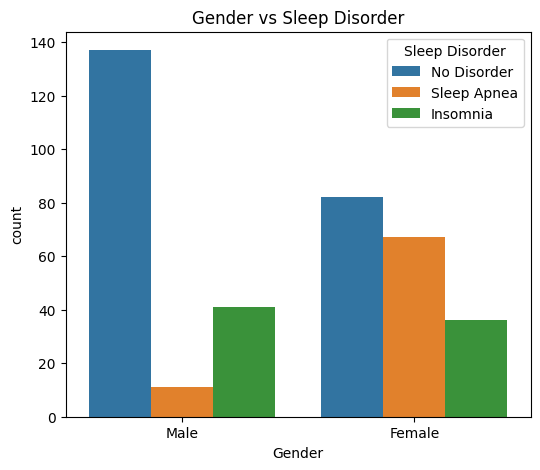

In [47]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x='Gender',
    hue='Sleep Disorder'
)

plt.title('Gender vs Sleep Disorder')
plt.show()

In [ ]:
"femals are having higher disorders compare with male"

In [61]:
(pd.crosstab(df["Occupation"],df["Sleep Disorder"],normalize="index")*100).round(2)

Sleep Disorder,Insomnia,No Disorder,Sleep Apnea
Occupation,,,
Accountant,18.92,81.08,0.00
Doctor,4.23,90.14,5.63
Engineer,7.94,90.48,1.59
Lawyer,4.26,89.36,6.38
Manager,0.00,100.00,0.00
Nurse,4.11,12.33,83.56
Sales Representative,0.00,0.00,100.00
Salesperson,90.62,6.25,3.12
Scientist,0.00,50.00,50.00


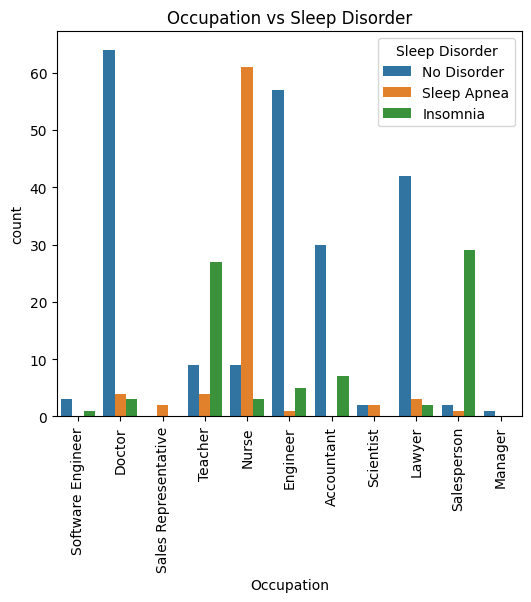

In [50]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x='Occupation',
    hue='Sleep Disorder'
)

plt.title('Occupation vs Sleep Disorder')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
"Nurse are having higher sleep apnea compare with any other profession"

In [63]:
(pd.crosstab(df["BMI Category"],df["Sleep Disorder"],normalize="index")*100).round(2)

Sleep Disorder,Insomnia,No Disorder,Sleep Apnea
BMI Category,,,
Normal,3.59,93.85,2.56
Normal Weight,9.52,80.95,9.52
Obese,40.00,0.00,60.00
Overweight,43.24,12.84,43.92


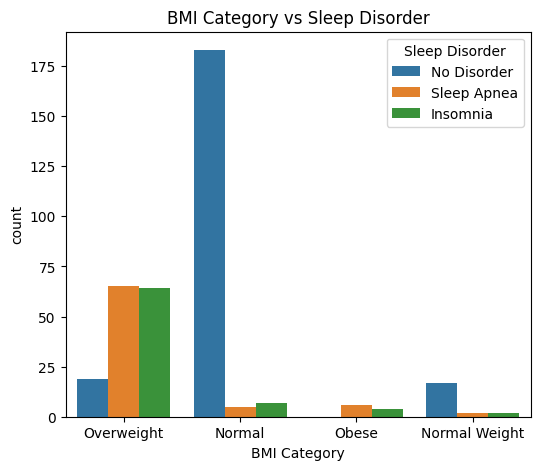

In [53]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x='BMI Category',
    hue='Sleep Disorder'
)

plt.title('BMI Category vs Sleep Disorder')
plt.show()

In [ ]:
"more weight,higher the disorders"

In [64]:
(pd.crosstab(df["Occupation"],df["BMI Category"],normalize="index")*100).round(2)

BMI Category,Normal,Normal Weight,Obese,Overweight
Occupation,,,,
Accountant,70.27,13.51,0.00,16.22
Doctor,91.55,2.82,5.63,0.00
Engineer,88.89,6.35,0.00,4.76
Lawyer,89.36,2.13,4.26,4.26
Manager,0.00,0.00,0.00,100.00
Nurse,0.00,9.59,0.00,90.41
Sales Representative,0.00,0.00,100.00,0.00
Salesperson,0.00,0.00,0.00,100.00
Scientist,0.00,0.00,0.00,100.00


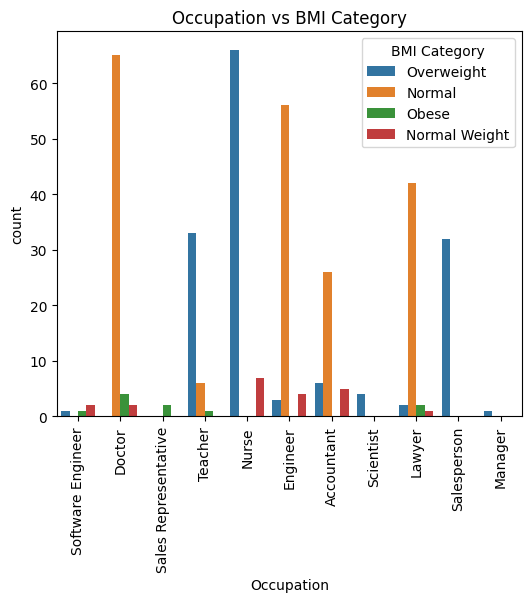

In [11]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x='Occupation',
    hue='BMI Category'
)

plt.title('Occupation vs BMI Category')
plt.xticks(rotation=90)
plt.show()

In [ ]:
"Nurse are comaparatively more weight than any other profession"

In [12]:
(pd.crosstab(df["Gender"],df["BMI Category"],normalize="index")*100).round(2)

BMI Category,Normal,Normal Weight,Obese,Overweight
Gender,,,,
Female,34.59,7.57,0.54,57.30
Male,69.31,3.70,4.76,22.22


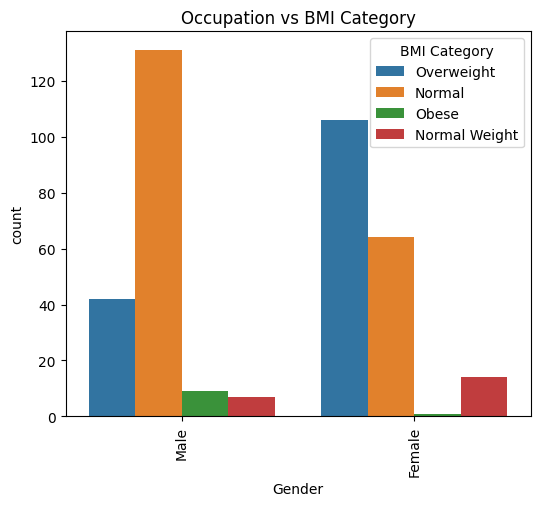

In [13]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x='Gender',
    hue='BMI Category'
)

plt.title('Occupation vs BMI Category')
plt.xticks(rotation=90)
plt.show()

In [ ]:
"Females are having more weight than the males.Hence,they are having higher number of sleep disorders despite of having more sleep duration.